In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

In [ ]:
X, Y = 30,30
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=None, V=None, F0_init=0.1)#,
                # F_init=[0.1, -0.1, 0.1j, -0.1j])

In [3]:
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_k(PI/3)))

True
True
True


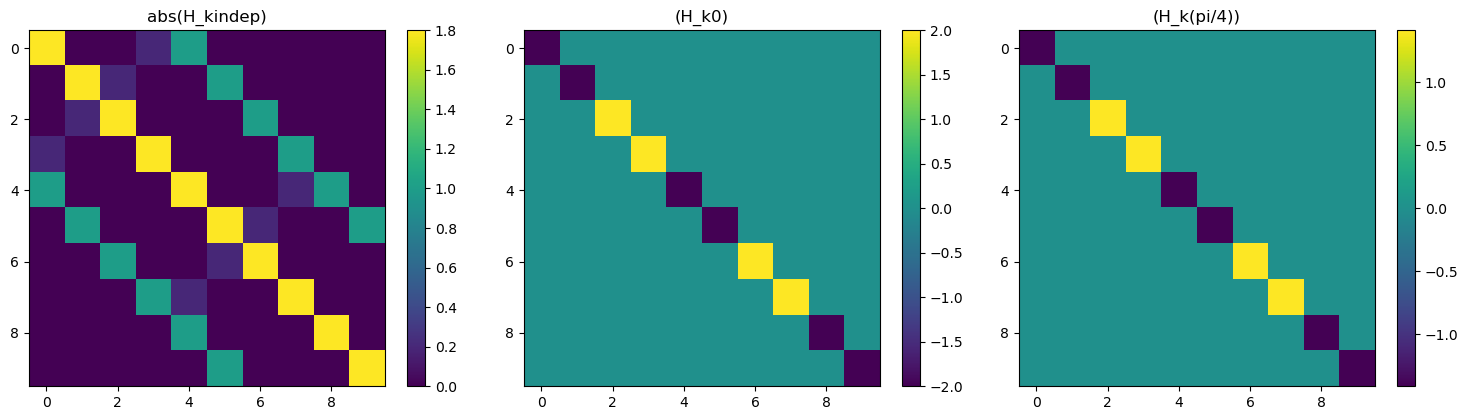

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

im0 = axs[0].imshow(np.abs(H.build_H_kindep())[0:10, 0:10])
axs[0].set_title("abs(H_kindep)")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(np.real(H.build_H_k0())[0:10, 0:10])
axs[1].set_title("(H_k0)")
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(np.real(H.build_H_k(PI/4))[0:10, 0:10])
axs[2].set_title("(H_k(pi/4))")
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()


In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1000, verbose=True, temperature=T)

d:\X-files\Master Thesis\master-thesis-codebase\scripts\utils.py:59: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp(energy / T) + 1.0)


Iteration 1:
F0:
Absolute error: 0.44734651229050554
Relative error: 4.47346512286032
Average old: (0.1+0j)
Average: (0.18131652479982513+0j)
F_xplus:
Absolute error: 0.2721093999913285
Relative error: 272109399991.3285
Average old: 0j
Average: (-0.05046606547629619+0j)
F_xmin:
Absolute error: 0.272109399991328
Relative error: 272109399991.32797
Average old: 0j
Average: (-0.05046606547629609+0j)
F_yplus:
Absolute error: 0.3113773501147046
Relative error: 311377350114.7045
Average old: 0j
Average: (-0.0559321420405215+2.7429351228618824e-17j)
F_ymin:
Absolute error: 0.3113773501147046
Relative error: 311377350114.7045
Average old: 0j
Average: (-0.0559321420405215-2.7429351228618824e-17j)
Iteration 2:
F0:
Absolute error: 0.5274048863880911
Relative error: 2.903330342441654
Average old: (0.18131652479982513+0j)
Average: (0.2774414247592841+0j)
F_xplus:
Absolute error: 0.10227793473450271
Relative error: 2.031319820953379
Average old: (-0.05046606547629619+0j)
Average: (-0.0694492913715010

In [6]:
F_yplus = H.F_yplus
F_ymin = H.F_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.F_xplus
F_xmin[1:]  = H.F_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

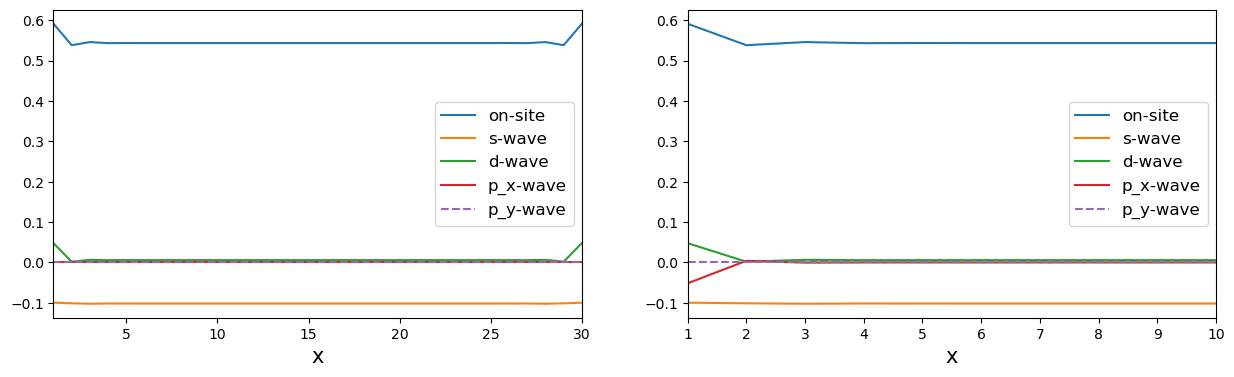

In [ ]:
x = np.arange(1, X + 1)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

axs[0].plot(x, np.real(F0), label="on-site")
axs[0].plot(x, np.real(F_swave), label="s-wave")
axs[0].plot(x, np.real(F_dwave), label="d-wave")
axs[0].plot(x, np.real(F_px), label="p_x-wave")
axs[0].plot(x, np.imag(F_py), "--", label="p_y-wave")
axs[0].set_xlabel("x", fontsize=15)
axs[0].set_xlim(1, X)
axs[0].legend(fontsize=12, loc="best")

axs[1].plot(x, np.real(F0), label="on-site")
axs[1].plot(x, np.real(F_swave2), label="s-wave")
axs[1].plot(x, np.real(F_dwave2), label="d-wave")
axs[1].plot(x, np.real(F_px2), label="p_x-wave")
axs[1].plot(x, np.imag(F_py2), "--", label="p_y-wave")
axs[1].set_xlabel("x", fontsize=15)
axs[1].set_xlim(1, 10)
axs[1].legend(fontsize=12, loc="best")

plt.show()

In [9]:
X, Y = 10, 100
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [10]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1000, verbose=True, temperature=T)


d:\X-files\Master Thesis\master-thesis-codebase\scripts\utils.py:59: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp(energy / T) + 1.0)


Iteration 1:
F0:
Absolute error: 5.04155670931232e-16
Relative error: 0.0005041556709312321
Average old: 0j
Average: (-1.4422409664108255e-17+0j)
F_xplus:
Absolute error: 0.03751598823693295
Relative error: 0.37515988236557785
Average old: (0.09999999999999999+0j)
Average: (0.10296923372106088+0j)
F_xmin:
Absolute error: 0.037515988236932696
Relative error: 0.3751598823730785
Average old: (-0.09999999999999999+0j)
Average: (-0.10296923372106061+0j)
F_yplus:
Absolute error: 0.11155654312008952
Relative error: 1.1155654312008951
Average old: 0.1j
Average: (3.681362398082202e-17+0.1346317892970572j)
F_ymin:
Absolute error: 0.11155654312008952
Relative error: 1.1155654312008951
Average old: -0.1j
Average: (3.681362398082202e-17-0.1346317892970572j)
Iteration 2:
F0:
Absolute error: 2.4913250355514496e-16
Relative error: 0.00024912459345611474
Average old: (-1.4422409664108255e-17+0j)
Average: (-4.1949285325187326e-17+0j)
F_xplus:
Absolute error: 0.02071186276474374
Relative error: 0.2022323

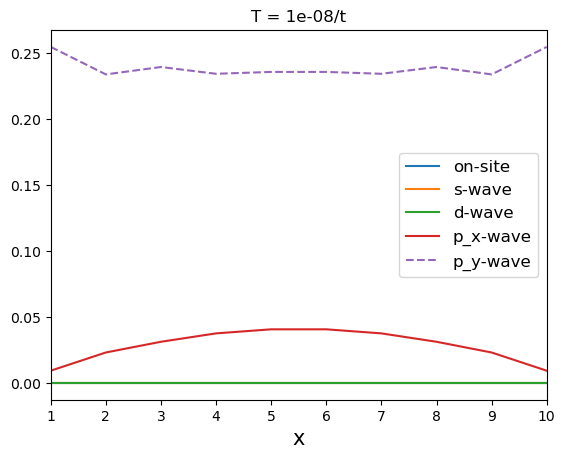

In [15]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.imag(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")